AVERAGED RESULTS ACROSS SESSIONS AND MICE

In [23]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import linregress

sns.set_theme(context='talk', style='ticks', palette='colorblind')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 'medium'
plt.rcParams['axes.titlelocation'] = 'left'

SCRATCH_DIR = '/scratch/rt_analysis'
DATA_DIR = os.path.join(SCRATCH_DIR, 'data')
FIGURE_DIR = os.path.join(SCRATCH_DIR, 'figures')
os.makedirs(FIGURE_DIR, exist_ok=True)

CONTEXT_ROWS = [('aud', 'Auditory'), ('vis', 'Visual')]
STREAK_COLUMNS = [('consecutive_rewarded', '# previous consecutive rewarded trials'), ('consecutive_unrewarded', '# previous consecutive unrewarded trials')]
OUTCOME_COLORS = {'hit': 'tab:blue', 'false alarm': 'tab:red'}
RT_OUTCOMES = ['hit', 'false alarm']
MAX_STREAK_LEVEL = {'consecutive_rewarded': 4, 'consecutive_unrewarded': 6}
MIN_TRIALS_PER_LEVEL = 3
MIN_SESSIONS_FOR_FIT = 3

# Load each session data
trial_files = sorted(glob.glob(os.path.join(DATA_DIR, '*__trials.csv')))
assert trial_files, 'no trials.csv files found in %s' % DATA_DIR
all_trials = pd.concat([pd.read_csv(f) for f in trial_files], ignore_index=True)
print('%d sessions, %d trials total' % (all_trials.session_id.nunique(), len(all_trials)))

analysis_trials = all_trials[all_trials.in_rt_analysis & all_trials.outcome.isin(RT_OUTCOMES) & all_trials.reaction_time.notna()]

# Median per streak and session
level_rows = []
for streak_column, _ in STREAK_COLUMNS:
    capped = analysis_trials[analysis_trials[streak_column] <= MAX_STREAK_LEVEL[streak_column]]
    grouped = capped.groupby(['session_id', 'rewarded_modality', 'outcome', streak_column]).reaction_time
    summary = grouped.agg(['median', 'size']).reset_index()
    summary.columns = ['session_id', 'context', 'outcome', 'streak_level', 'rt_median', 'n_trials']
    summary['streak'] = streak_column
    level_rows.append(summary)

level_medians = pd.concat(level_rows, ignore_index=True)
level_medians = level_medians[level_medians.n_trials >= MIN_TRIALS_PER_LEVEL]

12 sessions, 6247 trials total


Auditory, # previous consecutive rewarded trials, hit: slope -14.2 ms/trial (SE 12.7), p = 0.27, 59 session-levels from 12 sessions
Auditory, # previous consecutive rewarded trials, false alarm: slope -92.6 ms/trial (SE 48.1), p = 0.068, 23 session-levels from 12 sessions
Auditory, # previous consecutive unrewarded trials, hit: slope +5.8 ms/trial (SE 8.0), p = 0.47, 75 session-levels from 12 sessions
Auditory, # previous consecutive unrewarded trials, false alarm: slope +11.0 ms/trial (SE 10.1), p = 0.28, 51 session-levels from 11 sessions
Visual, # previous consecutive rewarded trials, hit: slope -24.8 ms/trial (SE 6.7), p = 0.00052, 58 session-levels from 12 sessions
Visual, # previous consecutive rewarded trials, false alarm: slope -3.8 ms/trial (SE 89.2), p = 0.97, 16 session-levels from 12 sessions
Visual, # previous consecutive unrewarded trials, hit: slope +12.0 ms/trial (SE 5.3), p = 0.026, 74 session-levels from 12 sessions
Visual, # previous consecutive unrewarded trials, fa

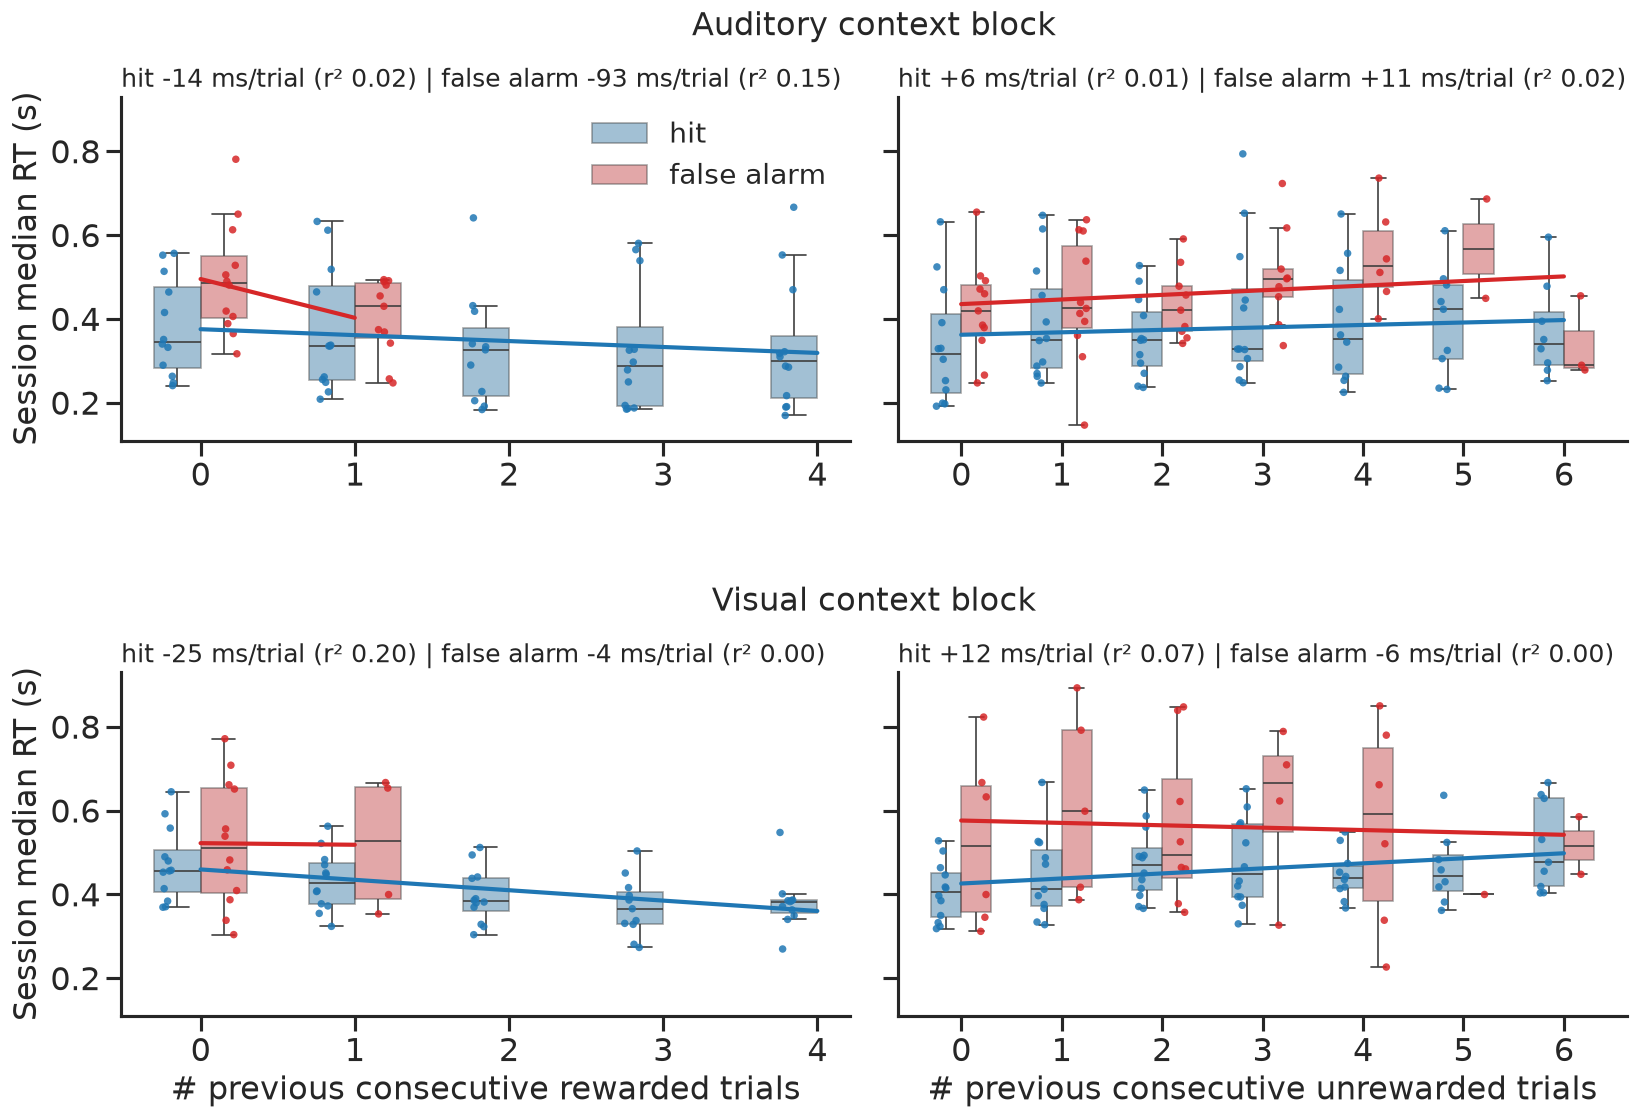

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
for row_index, (context_value, context_label) in enumerate(CONTEXT_ROWS):
    for col_index, (streak_column, column_label) in enumerate(STREAK_COLUMNS):
        ax = axes[row_index, col_index]
        panel_data = level_medians[(level_medians.context == context_value)
                                   & (level_medians.streak == streak_column)]
        if not len(panel_data):
            ax.set_title('no data', fontsize=11)
            sns.despine(ax=ax)
            continue
        level_order = sorted(panel_data.streak_level.unique())

        sns.boxplot(data=panel_data, x='streak_level', y='rt_median',
                    hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                    order=level_order, width=0.6, showfliers=False, linewidth=1,
                    boxprops={'alpha': 0.45},
                    legend=(row_index == 0 and col_index == 0), ax=ax)
        sns.stripplot(data=panel_data, x='streak_level', y='rt_median',
                      hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                      order=level_order, dodge=True, size=4.5, alpha=0.85,
                      linewidth=0, legend=False, ax=ax)

        position_by_level = {level: position for position, level in enumerate(level_order)}
        title_parts = []
        for outcome_label in RT_OUTCOMES:
            outcome_data = panel_data[panel_data.outcome == outcome_label]
            x = outcome_data.streak_level.map(position_by_level).values.astype(float)
            y = outcome_data.rt_median.values.astype(float)
            if len(x) < MIN_SESSIONS_FOR_FIT or len(np.unique(x)) < 2:
                title_parts.append('%s: not fitted' % outcome_label)
                continue
            result = linregress(x, y)
            x_line = np.array([x.min(), x.max()])
            ax.plot(x_line, result.intercept + result.slope * x_line, color=OUTCOME_COLORS[outcome_label], lw=2.5, zorder=5)
            title_parts.append('%s %+.0f ms/trial (r\u00b2 %.2f)' % (outcome_label, result.slope * 1e3, result.rvalue ** 2))
            print('%s, %s, %s: slope %+.1f ms/trial (SE %.1f), p = %.2g, '
                  '%d session-levels from %d sessions'
                  % (context_label, column_label, outcome_label,
                     result.slope * 1e3, result.stderr * 1e3, result.pvalue,
                     len(x), outcome_data.session_id.nunique()))

        ax.set_title(' | '.join(title_parts), fontsize=15)
        ax.set_xlabel(column_label if row_index == 1 else '', fontsize=19)
        ax.set_ylabel('Session median RT (s)' if col_index == 0 else '', fontsize=19)
        ax.tick_params(labelsize=19)
        sns.despine(ax=ax)

legend = axes[0, 0].get_legend()
if legend is not None:
    legend.set_title('')
    legend.prop.set_size(11)
    legend.get_frame().set_linewidth(0)

fig.tight_layout(rect=[0, 0, 1, 0.92], h_pad=5.0)

for row_index, (_, context_label) in enumerate(CONTEXT_ROWS):
    left_box = axes[row_index, 0].get_position()
    right_box = axes[row_index, 1].get_position()
    fig.text((left_box.x0 + right_box.x1) / 2, left_box.y1 + 0.045,
             '%s context block' % context_label,
             ha='center', va='bottom', fontsize=19)

fig.savefig(os.path.join(FIGURE_DIR, 'across_sessions__rt_vs_streak.png'), dpi=300, bbox_inches='tight')
plt.show()

Auditory, # previous consecutive rewarded trials, hit: slope -20.2 ms/trial (SE 5.3), r² = 0.019, p = 0.00015, 762 trials from 12 sessions
Auditory, # previous consecutive rewarded trials, FA: vis1: slope -96.7 ms/trial (SE 30.4), r² = 0.057, p = 0.0018, 169 trials from 12 sessions
Auditory, # previous consecutive rewarded trials, FA: vis2: slope +51.0 ms/trial (SE 98.2), r² = 0.009, p = 0.61, 31 trials from 10 sessions
Auditory, # previous consecutive rewarded trials, FA: sound2: slope -10.3 ms/trial (SE 28.9), r² = 0.001, p = 0.72, 173 trials from 12 sessions
Auditory, # previous consecutive unrewarded trials, hit: slope +6.6 ms/trial (SE 3.3), r² = 0.006, p = 0.045, 675 trials from 12 sessions
Auditory, # previous consecutive unrewarded trials, FA: vis1: slope +25.8 ms/trial (SE 10.4), r² = 0.042, p = 0.015, 141 trials from 12 sessions
Auditory, # previous consecutive unrewarded trials, FA: sound2: slope +13.6 ms/trial (SE 7.1), r² = 0.023, p = 0.055, 164 trials from 12 sessions
Vis

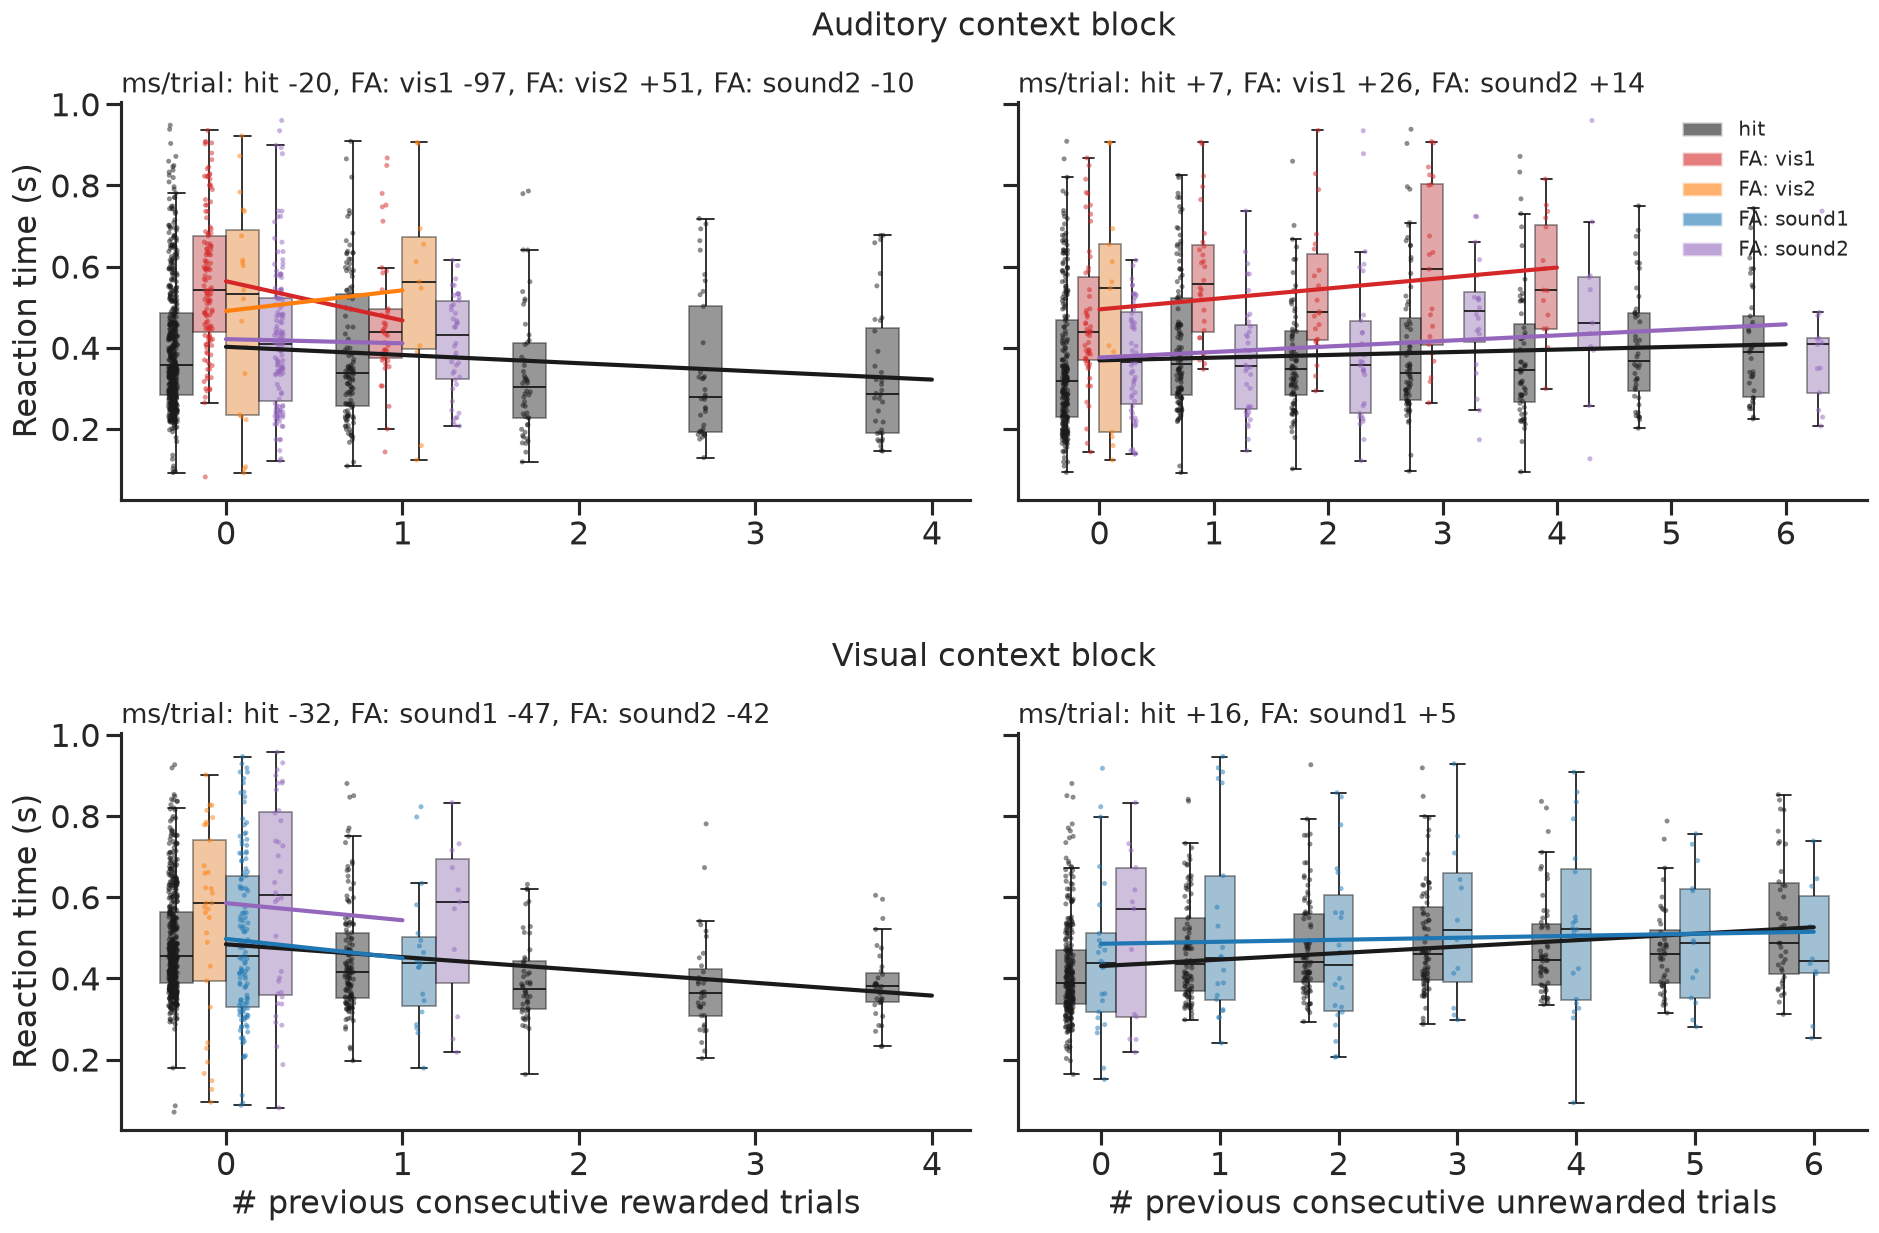

In [25]:
MIN_TRIALS_PER_LEVEL = 10      # a streak level enters a category only with this many trials

CONTEXT_ROWS = [('aud', 'Auditory'), ('vis', 'Visual')]
FA_STIM_COLORS = {'vis1': 'tab:red', 'vis2': 'tab:orange', 'sound1': 'tab:blue', 'sound2': 'tab:purple'}
HIT_COLOR = 'k'

# Split hits and false alarms(by stimulus)
pooled_data = analysis_trials[analysis_trials.outcome.isin(RT_OUTCOMES)].copy()
pooled_data['category'] = np.where(pooled_data.outcome == 'hit', 'hit', 'FA: ' + pooled_data.stim_name.astype(str))
category_palette = {'hit': HIT_COLOR}
category_palette.update({'FA: %s' % s: c for s, c in FA_STIM_COLORS.items()})
category_order_all = ['hit'] + ['FA: %s' % s for s in FA_STIM_COLORS]

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=True)
for row_index, (context_value, context_label) in enumerate(CONTEXT_ROWS):
    for col_index, (streak_column, column_label) in enumerate(STREAK_COLUMNS):
        ax = axes[row_index, col_index]
        panel_data = pooled_data[
            (pooled_data.rewarded_modality == context_value) & (pooled_data[streak_column] <= MAX_STREAK_LEVEL[streak_column])]

        # keep only (category, level) cells with enough trials behind them
        keep_mask = np.zeros(len(panel_data), dtype=bool)
        for category_label in panel_data.category.unique():
            category_mask = (panel_data.category == category_label).values
            level_counts = panel_data.loc[category_mask, streak_column].value_counts()
            kept_levels = level_counts[level_counts >= MIN_TRIALS_PER_LEVEL].index
            keep_mask |= (category_mask & panel_data[streak_column].isin(kept_levels).values)
        panel_data = panel_data[keep_mask]

        level_order = sorted(panel_data[streak_column].unique())
        category_order = [c for c in category_order_all if c in set(panel_data.category)]

        sns.boxplot(data=panel_data, x=streak_column, y='reaction_time',
                    hue='category', hue_order=category_order,
                    palette=category_palette, order=level_order,
                    width=0.75, showfliers=False, linewidth=1,
                    boxprops={'alpha': 0.45}, legend=False, ax=ax)
        sns.stripplot(data=panel_data, x=streak_column, y='reaction_time',
                      hue='category', hue_order=category_order,
                      palette=category_palette, order=level_order,
                      dodge=True, size=3, alpha=0.5,
                      linewidth=0, legend=False, ax=ax)

        position_by_level = {level: position for position, level in enumerate(level_order)}
        title_parts = []
        for category_label in category_order:
            category_data = panel_data[panel_data.category == category_label]
            x = category_data[streak_column].map(position_by_level).values.astype(float)
            y = category_data.reaction_time.values.astype(float)
            if len(np.unique(x)) < 2:
                continue
            result = linregress(x, y)
            x_line = np.array([x.min(), x.max()])
            ax.plot(x_line, result.intercept + result.slope * x_line, color=category_palette[category_label], lw=2.5, zorder=5)
            title_parts.append('%s %+.0f' % (category_label, result.slope * 1e3))
            print('%s, %s, %s: slope %+.1f ms/trial (SE %.1f), r\u00b2 = %.3f, '
                  'p = %.2g, %d trials from %d sessions'
                  % (context_label, column_label, category_label,
                     result.slope * 1e3, result.stderr * 1e3, result.rvalue ** 2,
                     result.pvalue, len(x), category_data.session_id.nunique()))

        ax.set_title('ms/trial: %s' % ', '.join(title_parts), fontsize=16)
        ax.set_xlabel(column_label if row_index == 1 else '', fontsize=19)
        ax.set_ylabel('Reaction time (s)' if col_index == 0 else '', fontsize=19)
        ax.tick_params(labelsize=19)
        sns.despine(ax=ax)

# legend built by hand so every category appears, not just those in one panel
legend_handles = [Patch(facecolor=category_palette[c], alpha=0.6, label=c) for c in category_order_all]
axes[0, 1].legend(handles=legend_handles, fontsize=12, frameon=False, loc='upper right')

fig.tight_layout(rect=[0, 0, 1, 0.92], h_pad=5.0)

# row titles centred over each pair of panels, added after tight_layout so the
# positions come from the final axes geometry
for row_index, (_, context_label) in enumerate(CONTEXT_ROWS):
    left_box = axes[row_index, 0].get_position()
    right_box = axes[row_index, 1].get_position()
    fig.text((left_box.x0 + right_box.x1) / 2, left_box.y1 + 0.045,
             '%s context block' % context_label, ha='center', va='bottom', fontsize=19)

fig.savefig(os.path.join(FIGURE_DIR, 'across_sessions__pooled_regression_by_stimulus.png'), dpi=300, bbox_inches='tight')
plt.show()

In [26]:
CONTEXT_LABELS = {'aud': 'Auditory', 'vis': 'Visual'}
CONTEXT_ORDER = ['aud', 'vis']
CONTEXT_PALETTE = {'aud': 'tab:purple', 'vis': 'tab:orange'}

session_slope_rows = []
for session_name, session_trials in analysis_trials.groupby('session_id'):
    for context_value in CONTEXT_ORDER:
        context_trials = session_trials[session_trials.rewarded_modality == context_value]
        for streak_column, streak_label in STREAK_COLUMNS:
            capped = context_trials[context_trials[streak_column] <= MAX_STREAK_LEVEL[streak_column]]
            for outcome_label in RT_OUTCOMES:
                outcome_data = capped[capped.outcome == outcome_label]
                x = outcome_data[streak_column].values.astype(float)
                y = outcome_data.reaction_time.values.astype(float)
                if len(np.unique(x)) < 2:
                    continue
                result = linregress(x, y)
                session_slope_rows.append({
                    'session_id': session_name,
                    'context': context_value,
                    'streak': streak_column,
                    'streak_label': streak_label,
                    'outcome': outcome_label,
                    'slope_ms': result.slope * 1e3,
                    'se_ms': result.stderr * 1e3,
                    'p': result.pvalue,
                    'n': len(x)})

session_slopes = pd.DataFrame(session_slope_rows)

excluded 6 of 96 fits with |slope| > 100 ms/trial


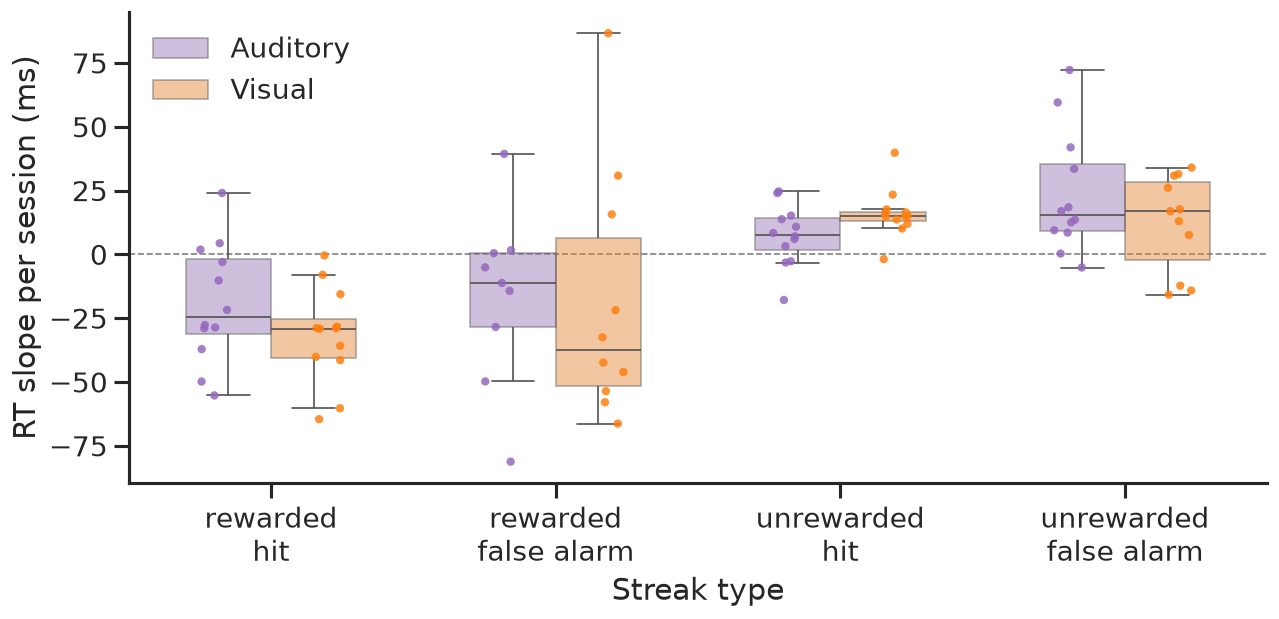

In [27]:
MAX_ABS_SLOPE_MS = 100     # drop fits with |slope| above this, in ms per streak trial

n_before = len(session_slopes)
plot_slopes = session_slopes[session_slopes.slope_ms.abs() <= MAX_ABS_SLOPE_MS]
print('excluded %d of %d fits with |slope| > %d ms/trial' % (n_before - len(plot_slopes), n_before, MAX_ABS_SLOPE_MS))
plot_slopes = plot_slopes.copy()
plot_slopes['group'] = plot_slopes.apply(lambda r: '%s\n%s' % ('unrewarded' if 'unrewarded' in r.streak else 'rewarded', r.outcome), axis=1)
group_order = ['rewarded\nhit', 'rewarded\nfalse alarm', 'unrewarded\nhit', 'unrewarded\nfalse alarm']
group_order = [g for g in group_order if g in set(plot_slopes.group)]

fig, ax = plt.subplots(figsize=(11, 5.5))

sns.boxplot(data=plot_slopes, x='group', y='slope_ms', hue='context',
            hue_order=CONTEXT_ORDER, palette=CONTEXT_PALETTE, order=group_order,
            width=0.6, showfliers=False, linewidth=1,
            boxprops={'alpha': 0.45}, ax=ax)
sns.stripplot(data=plot_slopes, x='group', y='slope_ms', hue='context',
              hue_order=CONTEXT_ORDER, palette=CONTEXT_PALETTE, order=group_order,
              dodge=True, size=5, alpha=0.85, linewidth=0, legend=False, ax=ax)

legend = ax.get_legend()
if legend is not None:
    legend.set_title('')
    for text, context_value in zip(legend.get_texts(), CONTEXT_ORDER):
        text.set_text(CONTEXT_LABELS[context_value])
    legend.prop.set_size(9)
    legend.get_frame().set_linewidth(0)

ax.axhline(0, color='0.5', lw=1, ls='--', zorder=0)
ax.set_xlabel('Streak type')
ax.set_ylabel('RT slope per session (ms)')
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, 'across_sessions__per_session_slopes.png'), dpi=300, bbox_inches='tight')
plt.show()

MICE DIFFERENCES

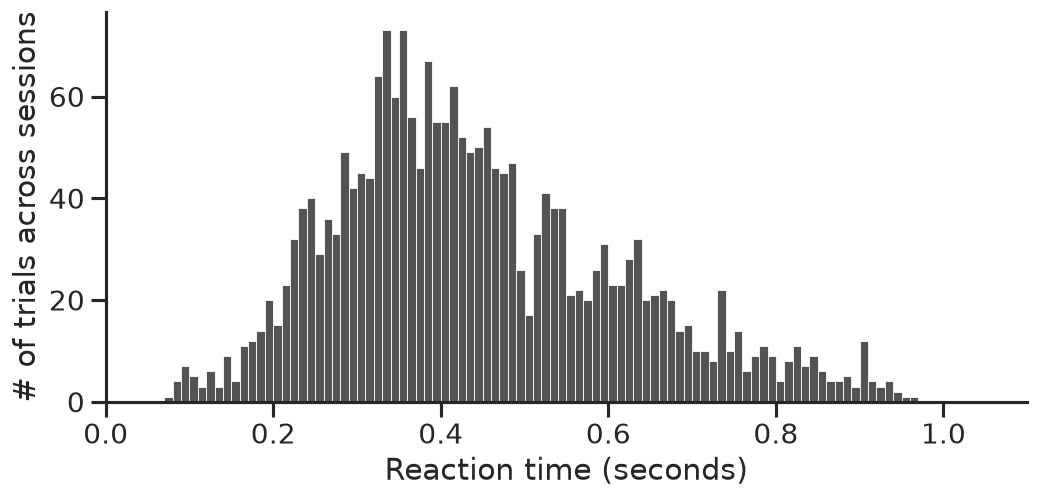

In [28]:
trial_files = sorted(glob.glob(os.path.join(DATA_DIR, '*__trials.csv')))
assert trial_files, 'no trials.csv files found in %s' % DATA_DIR
all_trials = pd.concat([pd.read_csv(f) for f in trial_files], ignore_index=True)

rt_all = all_trials[all_trials.in_rt_analysis & all_trials.reaction_time.notna()]

RT_BIN_WIDTH = 0.01
RT_AXIS_LIMITS = (0, 1.1)

fig, ax = plt.subplots(figsize=(9, 4.5))

sns.histplot(x=rt_all.reaction_time, binwidth=RT_BIN_WIDTH, binrange=(0, RT_AXIS_LIMITS[1]), color='k', edgecolor='white', linewidth=0.5, ax=ax)

ax.set_xlim(*RT_AXIS_LIMITS)
ax.set_xlabel('Reaction time (seconds)')
ax.set_ylabel('# of trials across sessions')
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, 'across_sessions__rt_histogram.png'), dpi=300, bbox_inches='tight')
plt.show()

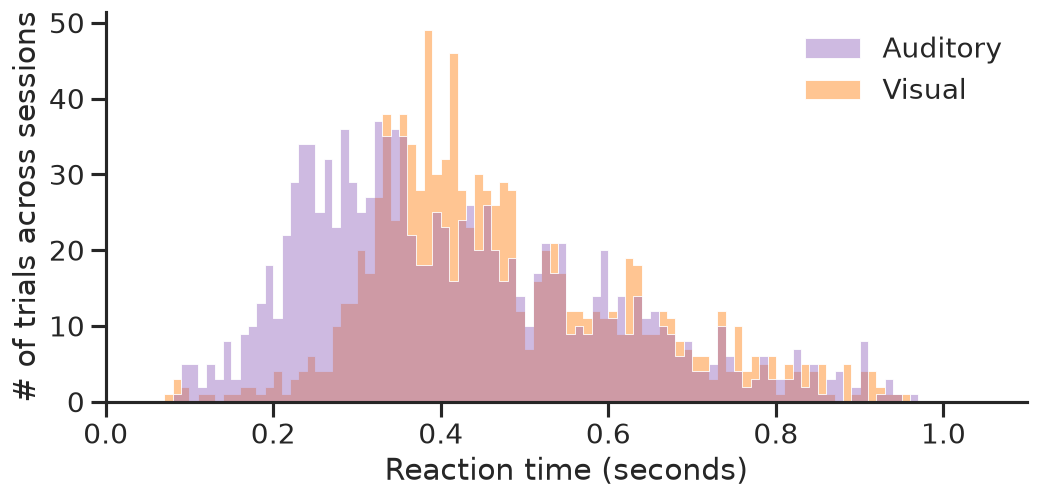

In [29]:
CONTEXT_ORDER = ['aud', 'vis']
CONTEXT_PALETTE = {'aud': 'tab:purple', 'vis': 'tab:orange'}
CONTEXT_LABELS = {'aud': 'Auditory', 'vis': 'Visual'}

fig, ax = plt.subplots(figsize=(9, 4.5))

sns.histplot(data=rt_all, x='reaction_time', hue='rewarded_modality',
             hue_order=CONTEXT_ORDER, palette=CONTEXT_PALETTE,
             binwidth=RT_BIN_WIDTH, binrange=(0, RT_AXIS_LIMITS[1]),
             element='step', fill=True, alpha=0.45,
             edgecolor='white', linewidth=0.5, ax=ax)

ax.set_xlim(*RT_AXIS_LIMITS)
ax.set_xlabel('Reaction time (seconds)')
ax.set_ylabel('# of trials across sessions')
sns.despine(ax=ax)

legend = ax.get_legend()
if legend is not None:
    legend.set_title('')
    for text, context_value in zip(legend.get_texts(), CONTEXT_ORDER):
        text.set_text(CONTEXT_LABELS[context_value])
    legend.prop.set_size(9)
    legend.get_frame().set_linewidth(0)

fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, 'across_sessions__rt_histogram_by_context.png'), dpi=300, bbox_inches='tight')
plt.show()

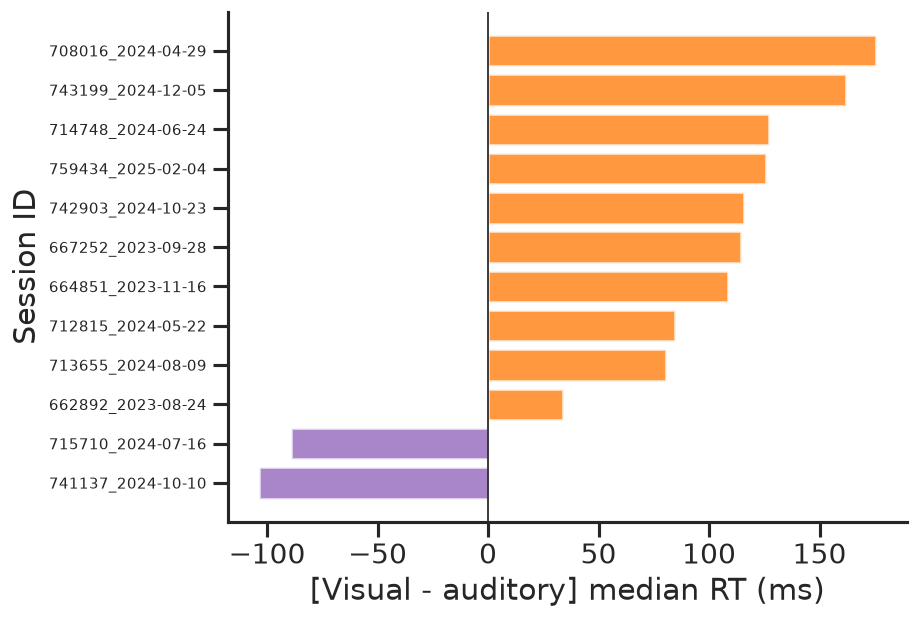

In [30]:
hit_trials = analysis_trials[analysis_trials.outcome == 'hit']

context_medians = (hit_trials.groupby(['session_id', 'rewarded_modality']).reaction_time.median().unstack())
context_medians['difference_ms'] = (context_medians.vis - context_medians.aud) * 1e3
context_medians = context_medians.sort_values('difference_ms')

fig, ax = plt.subplots(figsize=(8, 5.5))
bar_colors = [CONTEXT_PALETTE['vis'] if d > 0 else CONTEXT_PALETTE['aud'] for d in context_medians.difference_ms]
ax.barh(np.arange(len(context_medians)), context_medians.difference_ms, color=bar_colors, alpha=0.8)
ax.axvline(0, color='k', lw=1)
ax.set_yticks(np.arange(len(context_medians)))
ax.set_yticklabels(context_medians.index, fontsize=9)
ax.set_xlabel('[Visual - auditory] median RT (ms)')
ax.set_ylabel('Session ID')
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, 'across_sessions__context_rt_difference.png'), dpi=300, bbox_inches='tight')
plt.show()

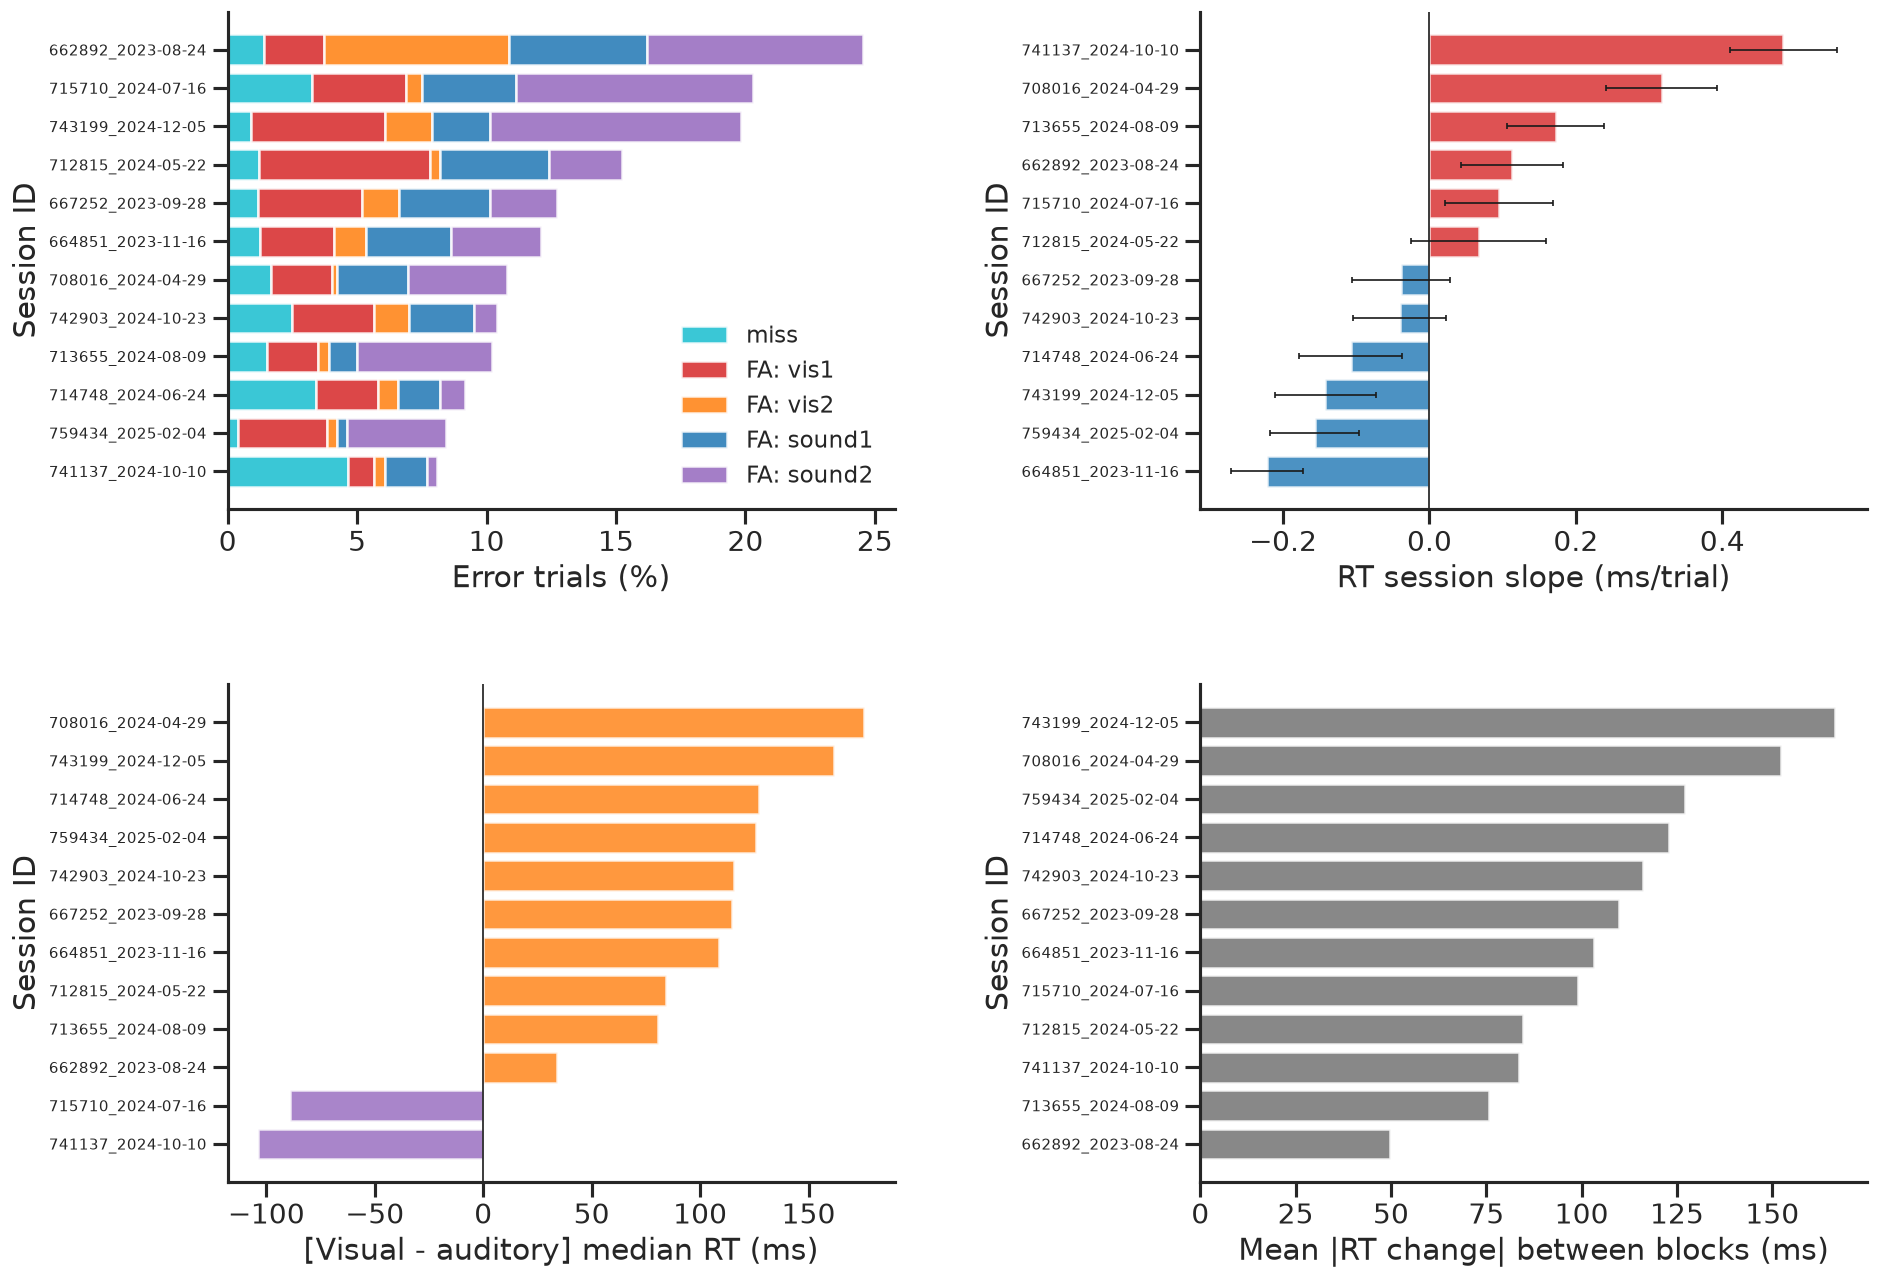

In [31]:
# Take hit trials
hit_trials = analysis_trials[analysis_trials.outcome == 'hit']

# Error trials
error_rows = []
for session_name, session_trials_all in all_trials.groupby('session_id'):
    non_catch = session_trials_all[~session_trials_all.is_catch] # Catch trials not used
    n_total = max(len(non_catch), 1)
    row = {'session_id': session_name, 'miss': 100 * non_catch.is_miss.sum() / n_total}
    for stim_name in FA_STIM_COLORS: # False alarm by stimuli
        n_fa = ((non_catch.stim_name == stim_name) & non_catch.is_false_alarm).sum()
        row['FA: %s' % stim_name] = 100 * n_fa / n_total
    error_rows.append(row)
error_table = pd.DataFrame(error_rows).set_index('session_id')
error_table['total'] = error_table.sum(axis=1)
error_table = error_table.sort_values('total')

# Slope of RT across the full session (only hits)
slope_rows = []
for session_name, session_hits in hit_trials.groupby('session_id'):
    x = session_hits.trial_position.values.astype(float)
    y = session_hits.reaction_time.values.astype(float)
    result = linregress(x, y)
    slope_rows.append({'session_id': session_name,
                       'slope_ms_per_trial': result.slope * 1e3,
                       'se_ms': result.stderr * 1e3,
                       'p': result.pvalue, 'n_hits': len(x)})
slope_table_session = pd.DataFrame(slope_rows).set_index('session_id').sort_values('slope_ms_per_trial')

# Visual and auditory RT difference
context_medians = (hit_trials.groupby(['session_id', 'rewarded_modality']).reaction_time.median().unstack())
context_medians['difference_ms'] = (context_medians.vis - context_medians.aud) * 1e3
context_medians = context_medians.sort_values('difference_ms')

# RT discriminalibity between blocks
block_medians = (hit_trials.groupby(['session_id', 'block_index']).reaction_time.agg(['median', 'size']).reset_index())
block_medians.columns = ['session_id', 'block_index', 'rt_median', 'n_hits']

switch_rows = []
for session_name, session_blocks in block_medians.groupby('session_id'):
    session_blocks = session_blocks.sort_values('block_index')
    differences = np.diff(session_blocks.rt_median.values) * 1e3
    if not len(differences):
        continue
    switch_rows.append({'session_id': session_name,
                        'mean_abs_change_ms': np.mean(np.abs(differences)),
                        'mean_signed_change_ms': np.mean(differences),
                        'n_switches': len(differences)})
switch_table = pd.DataFrame(switch_rows).set_index('session_id').sort_values('mean_abs_change_ms')

# Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
ax = axes[0, 0]
left_edge = np.zeros(len(error_table))
for column_name, bar_color in [('miss', 'tab:cyan')] + [
        ('FA: %s' % s, c) for s, c in FA_STIM_COLORS.items()]:
    if column_name not in error_table:
        continue
    ax.barh(np.arange(len(error_table)), error_table[column_name], left=left_edge, color=bar_color, alpha=0.85, label=column_name)
    left_edge = left_edge + error_table[column_name].values
ax.set_yticks(np.arange(len(error_table)))
ax.set_yticklabels(error_table.index, fontsize=9)
ax.set_xlabel('Error trials (%)')
ax.set_ylabel('Session ID')
ax.legend(fontsize=14, frameon=False, loc='lower right')
sns.despine(ax=ax)

ax = axes[0, 1]
ax.barh(np.arange(len(slope_table_session)), slope_table_session.slope_ms_per_trial,
        color=['tab:red' if s > 0 else 'tab:blue'
               for s in slope_table_session.slope_ms_per_trial], alpha=0.8)
ax.errorbar(slope_table_session.slope_ms_per_trial,
            np.arange(len(slope_table_session)), xerr=slope_table_session.se_ms,
            fmt='none', ecolor='k', lw=1, capsize=2)
ax.axvline(0, color='k', lw=1)
ax.set_yticks(np.arange(len(slope_table_session)))
ax.set_yticklabels(slope_table_session.index, fontsize=9)
ax.set_xlabel('RT session slope (ms/trial)')
ax.set_ylabel('Session ID')
sns.despine(ax=ax)

ax = axes[1, 0]
ax.barh(np.arange(len(context_medians)), context_medians.difference_ms,
        color=[CONTEXT_PALETTE['vis'] if d > 0 else CONTEXT_PALETTE['aud']
               for d in context_medians.difference_ms], alpha=0.8)
ax.axvline(0, color='k', lw=1)
ax.set_yticks(np.arange(len(context_medians)))
ax.set_yticklabels(context_medians.index, fontsize=9)
ax.set_xlabel('[Visual - auditory] median RT (ms)')
ax.set_ylabel('Session ID')
sns.despine(ax=ax)

ax = axes[1, 1]
ax.barh(np.arange(len(switch_table)), switch_table.mean_abs_change_ms,color='0.45', alpha=0.85)
ax.set_yticks(np.arange(len(switch_table)))
ax.set_yticklabels(switch_table.index, fontsize=9)
ax.set_xlabel('Mean |RT change| between blocks (ms)')
ax.set_ylabel('Session ID')
sns.despine(ax=ax)

fig.tight_layout(h_pad=3.0, w_pad=3.0)
fig.savefig(os.path.join(FIGURE_DIR, 'across_sessions__session_summary.png'), dpi=300, bbox_inches='tight')
plt.show()

MOTOR AND REACTION TIME CORRELATION

saved /scratch/rt_analysis/figures/662892_2023-08-24__rt_and_features_timecourse.png


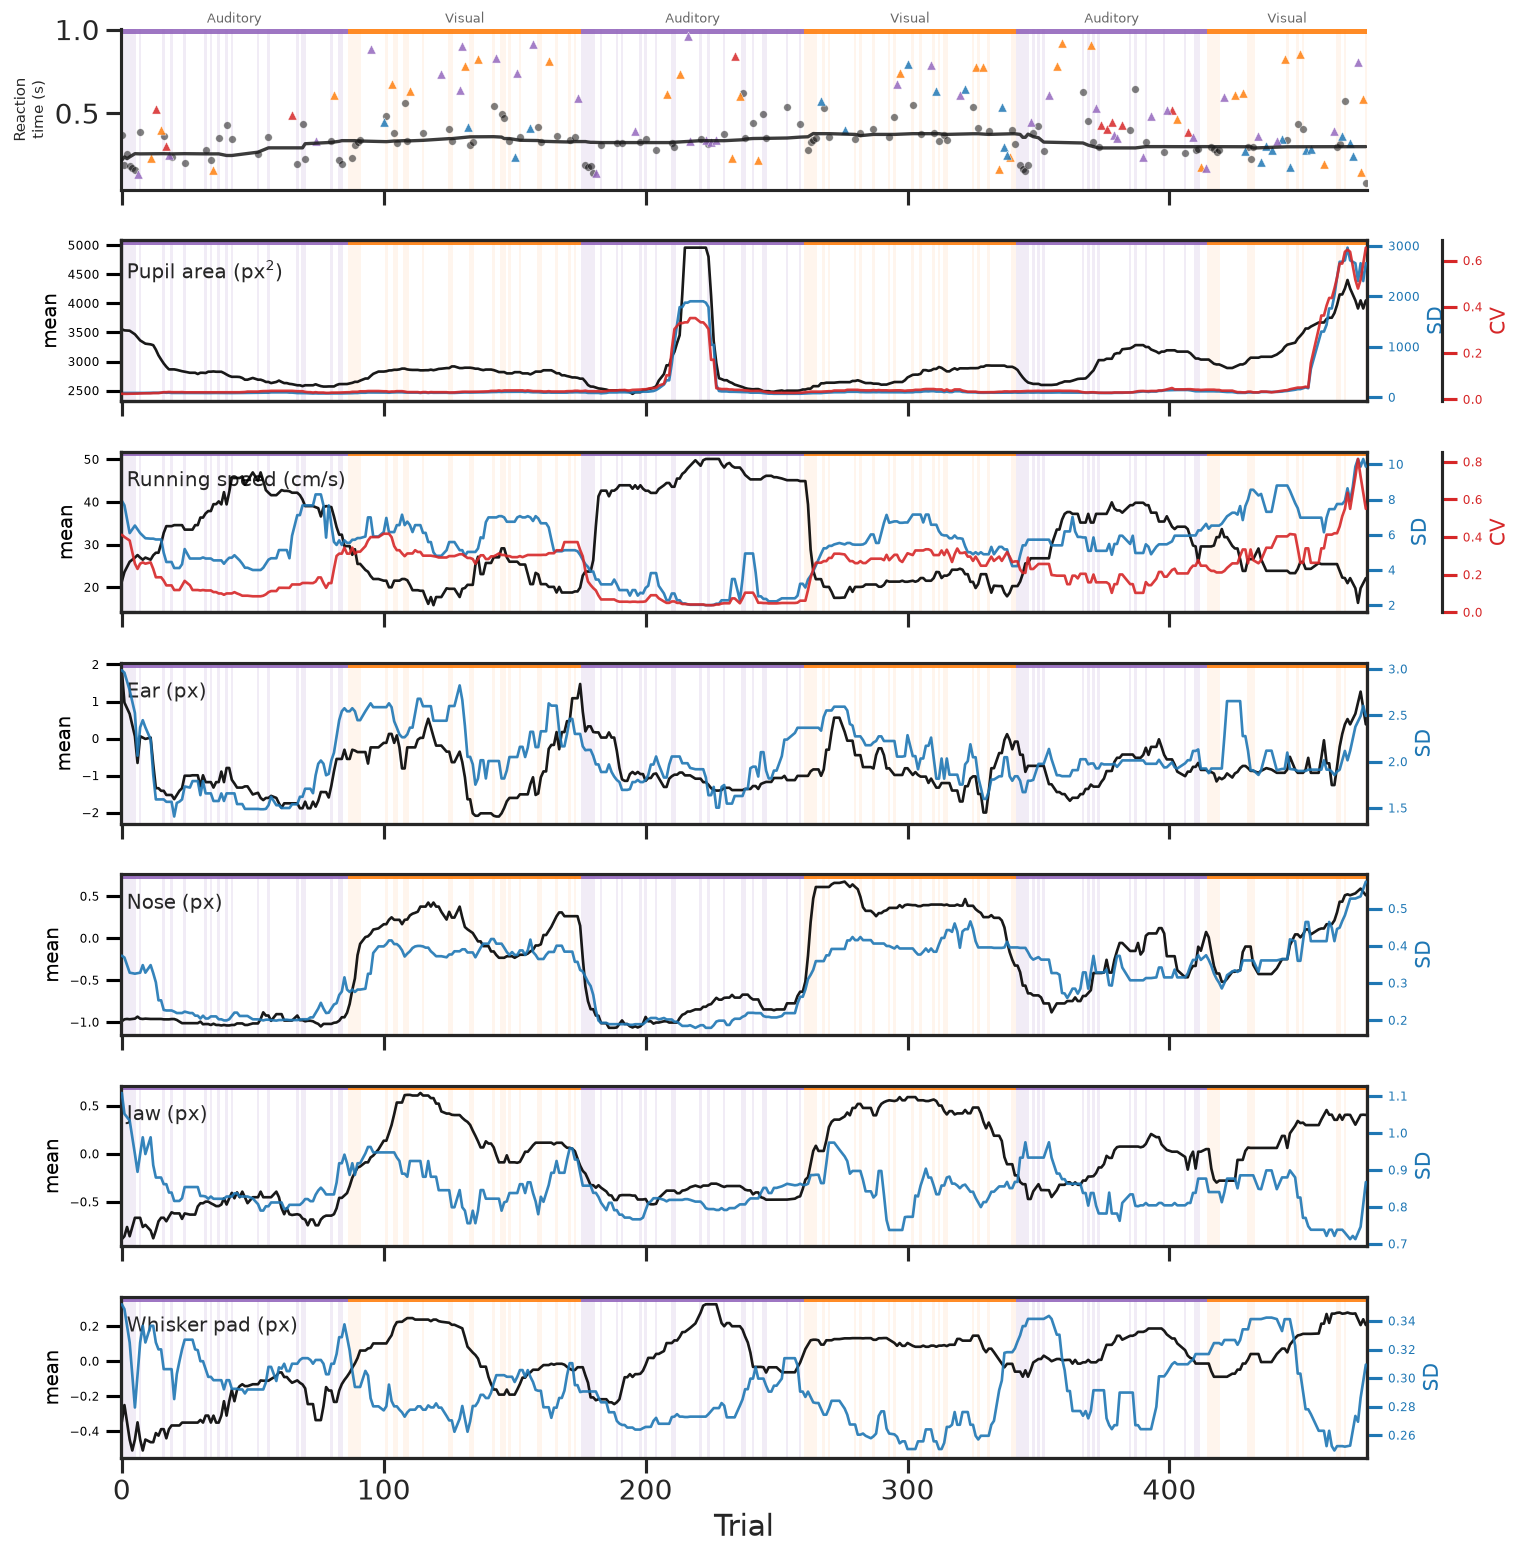

In [45]:
VARIABLE_ORDER = ['pupil_area', 'running_speed', 'ear', 'nose', 'jaw', 'whiskers']
CV_VARIABLES = ['pupil_area', 'running_speed']
SHOW_STATISTICS = ['_mean', '_sd', '_cv']
VARIABLE_LABELS = {'pupil_area': 'Pupil area (px$^2$)',
                   'running_speed': 'Running speed (cm/s)',
                   'ear': 'Ear (px)', 'nose': 'Nose (px)',
                   'jaw': 'Jaw (px)', 'whiskers': 'Whisker pad (px)'}
STATISTIC_COLORS = {'_mean': 'black', '_sd': 'tab:blue', '_cv': 'tab:red'}
STATISTIC_LABELS = {'_mean': 'mean', '_sd': 'SD', '_cv': 'CV'}
RUNNING_WINDOW = 20

PLOT_SESSION_NUMBER = 0        # <-- change this to switch session

CONTEXT_SHADE = {'vis': ('tab:orange', 0.07), 'aud': ('tab:purple', 0.12)}

trial_files = sorted(glob.glob(os.path.join(DATA_DIR, '*__trials.csv')))
behavior_files = sorted(glob.glob(os.path.join(DATA_DIR,'*__behavior_trialwise.csv')))
all_trials = pd.concat([pd.read_csv(f) for f in trial_files], ignore_index=True)
all_behavior = pd.concat([pd.read_csv(f) for f in behavior_files], ignore_index=True)
behavior_columns = ['session_id', 'trial_position'] + [
    c for c in all_behavior.columns
    if c.endswith(('_mean', '_sd', '_cv', '_n_samples'))]
merged = all_trials.merge(all_behavior[behavior_columns], on=['session_id', 'trial_position'], how='left')

available_sessions = sorted(merged.session_id.unique())
plot_session_id = available_sessions[PLOT_SESSION_NUMBER]
session_data = merged[merged.session_id == plot_session_id].sort_values('trial_position').reset_index(drop=True)
variables_present = [v for v in VARIABLE_ORDER if v + '_mean' in session_data]
n_panels = 1 + len(variables_present)

fig, axes = plt.subplots(n_panels, 1, figsize=(13, 1.9 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]

block_index_array = session_data.block_index.values
context_array = session_data.rewarded_modality.values
rewarded_array = session_data.is_rewarded.values

for ax in axes:
    for trial_position in np.flatnonzero(rewarded_array):
        shade_color, shade_alpha = CONTEXT_SHADE[context_array[trial_position]]
        ax.axvspan(trial_position - 0.5, trial_position + 0.5,
                   color=shade_color, alpha=shade_alpha, lw=0, zorder=0)
    for block_index in np.unique(block_index_array):
        in_block = np.flatnonzero(block_index_array == block_index)
        shade_color, _ = CONTEXT_SHADE[context_array[in_block[0]]]
        ax.axvspan(in_block[0] - 0.5, in_block[-1] + 0.5,
                   ymin=0.97, ymax=1.0, color=shade_color, alpha=0.9, lw=0, zorder=1)

for block_index in np.unique(block_index_array):
    in_block = np.flatnonzero(block_index_array == block_index)
    axes[0].annotate(CONTEXT_LABELS[context_array[in_block[0]]],
                     ((in_block[0] + in_block[-1]) / 2, 1.02),
                     xycoords=('data', 'axes fraction'),
                     ha='center', va='bottom', fontsize=8, color='0.4')

# RT
ax = axes[0]
hit_data = session_data[(session_data.outcome == 'hit') & session_data.reaction_time.notna()]
ax.scatter(hit_data.trial_position, hit_data.reaction_time,
           s=20, alpha=0.5, marker='o', color='black',
           edgecolor='white', linewidth=0.3, zorder=2, label='hit')

fa_data = session_data[(session_data.outcome == 'false alarm') & session_data.reaction_time.notna()]
for stim_name in [s for s in FA_STIM_COLORS if s in set(fa_data.stim_name)]:
    stim_subset = fa_data[fa_data.stim_name == stim_name]
    ax.scatter(stim_subset.trial_position, stim_subset.reaction_time,
               s=30, alpha=0.85, marker='^', color=FA_STIM_COLORS[stim_name],
               edgecolor='white', linewidth=0.3, zorder=3,
               label='FA: %s' % stim_name)

running_rt = hit_data.reaction_time.rolling(RUNNING_WINDOW, min_periods=5, center=True).median()
ax.plot(hit_data.trial_position, running_rt, color='k', lw=2, alpha=0.85, zorder=4)
ax.set_ylabel('Reaction\ntime (s)', fontsize=9)
sns.despine(ax=ax)

# Feature variable
for panel_index, variable_name in enumerate(variables_present, start=1):
    ax = axes[panel_index]
    statistics_here = [s for s in SHOW_STATISTICS
                       if variable_name + s in session_data
                       and (s != '_cv' or variable_name in CV_VARIABLES)]

    axis_offset = 0
    for statistic_suffix in statistics_here:
        feature_column = variable_name + statistic_suffix
        feature_data = session_data[~session_data.is_catch & session_data[feature_column].notna()]
        if statistic_suffix == statistics_here[0]:
            target_ax = ax
        else:
            target_ax = ax.twinx()
            axis_offset += 1
            if axis_offset > 1:
                target_ax.spines['right'].set_position(('axes', 1 + 0.06 * (axis_offset - 1)))
        statistic_color = STATISTIC_COLORS[statistic_suffix]
        running_feature = feature_data[feature_column].rolling(RUNNING_WINDOW, min_periods=5, center=True).median()
        target_ax.plot(feature_data.trial_position, running_feature, color=statistic_color, lw=1.6, alpha=0.9, zorder=4)
        target_ax.set_ylabel(STATISTIC_LABELS[statistic_suffix], fontsize=12, color=statistic_color)
        target_ax.tick_params(axis='y', labelsize=7, colors=statistic_color)

    ax.annotate(VARIABLE_LABELS[variable_name], (0.005, 0.88), xycoords='axes fraction', fontsize=12, va='top')
    sns.despine(ax=ax, right=False)

axes[-1].set_xlabel('Trial')
axes[0].set_xlim(-0.5, len(session_data) - 0.5)
fig.tight_layout()
out_path = os.path.join(FIGURE_DIR, '%s__rt_and_features_timecourse.png' % plot_session_id)
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print('saved %s' % out_path)
plt.show()